# Pre-analysis

Stage 1 of 3 of the analysis plan ([`final-analysis-plan.md`](../../docs/analysis/final-analysis-plan.md) §3). It checks what the
core analysis (`02_core_analysis.ipynb`) relies on. **None of these checks regresses the outcome
on the treatment or the instrument**: there is no reduced form, no TWFE of LST on lights and no
2SLS here.

The specification is fixed in `src/analysis/spec.py` (plan §2). It regresses night LST
(MYD21A2) on `log1p(ntl_harm)`, instrumented by `mine_count_20km`, with pixel + country × biome
× year FE, SEs clustered by ADM1 and flares dropped, on the 10 km panel for 2002–2022.

| Block | Check | ◇ Rule (plan §3) |
|---|---|---|
| P1 | panel and sample | |
| P2 | treatment series: DMSP→VIIRS, flares | |
| P3 | does the clear-sky composite select on lights, mines or haze? | selection is material if d `cov_night` / d lights > 0.01 → C1 adds a coverage-restricted TWFE |
| P4 | instrument: variation, balance, first stage, π profile | F < 10 → AR only |
| P5 | does ACAG PM2.5 carry cell-local variation? | within-FE r² with ring-1 mean ≥ 0.9 → C4 speaks to regional aerosol only |

Engine: `duckreg` on the full panel (~25 M pixel-years). A two-way-FE fit takes 1–3 min.

In [1]:
import sys
from pathlib import Path
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
from src.analysis.spec import (   # the fixed specification (plan §2)
    PANEL, NTL_HI, COV_MIN, Y, Y_DAY, XLOG, Z, M, FE, FE_CTY, BASE,
    build_panel, fit, row, reg_table, first_stage_F,
)

build_panel()                     # cached: <data>/_analysis_panel_10km.parquet
P = f"read_parquet('{PANEL}')"  # for DuckDB queries on the panel
sql = lambda q: duckdb.sql(q).df()


built /scicore/home/meiera/schulz0022/projects/growth-and-temperature/data_nobackup/_analysis_panel_10km.parquet in 57s (1808 MB)


## P1. Panel and sample

In [2]:
display(sql(f"""
    SELECT count(*) AS pixel_years, count(DISTINCT pixel_id) AS pixels, count(DISTINCT GID_0) AS countries,
           min(year) AS y0, max(year) AS y1, sum(is_flare) AS flare_rows_dropped
    FROM {P}"""))

cols = [Y, Y_DAY, "ntl_harm", XLOG, Z, M, "cov_night", "cov_day"]
pd.concat([sql(f"""
    SELECT '{c}' AS var, avg({c}) AS mean, stddev_samp({c}) AS sd,
           quantile_cont({c}, 0.01) AS p1, median({c}) AS p50, quantile_cont({c}, 0.99) AS p99,
           avg(({c} IS NULL)::INT) AS share_null, avg(({c} = 0)::INT) AS share_zero
    FROM {P} WHERE {BASE}""") for c in cols]).set_index("var").round(3)

,pixel_years,pixels,countries,y0,y1,flare_rows_dropped
0,25268139,1205481,253,2002,2022,134375.0


,mean,sd,p1,p50,p99,share_null,share_zero
var,,,,,,,
lst_night_mean,284.455,11.185,258.960,287.667,300.362,0.000,0.000
lst_day_mean,303.316,13.616,271.843,306.599,324.619,0.001,0.000
ntl_harm,3.117,9.997,0.000,0.000,56.560,0.000,0.656
log_ntl,0.532,1.012,0.000,0.000,4.053,0.000,0.656
mine_count_20km,0.058,0.384,0.000,0.000,1.430,0.000,0.942
pm25,19.096,14.805,3.309,14.130,69.771,0.000,0.000
cov_night,0.888,0.177,0.260,0.978,1.000,0.000,0.000
cov_day,0.866,0.196,0.179,0.956,1.000,0.000,0.001


**Result.** 25.27 M pixel-years, 1.21 M pixels, 253 countries, 2002–2022. The flare mask drops
134 k pixel-years. Night LST: mean 284.5 K, sd 11.2 K. `ntl_harm` is exactly zero in 65.6 % of
pixel-years. `mine_count_20km` is zero in 94.2 %. PM2.5: mean 19.1 µg/m³ (p1–p99 3.3–69.8). No
variable in the specification is missing more than 0.1 % within the night-LST panel.

**Interpretation.** The sample is the one the former `regression.ipynb` used, same rows, so
the carried-over post-analysis outputs stay comparable. PM2.5 is available on essentially every
pixel-year, so C4's PM2.5 sample is the full panel.

## P2. Treatment series

`ntl_harm` splices DMSP-OLS to a VIIRS-based series around 2013. At DN 7 the lit share swings
at the splice. The fixed specification uses `NTL_HI = 20`. Below: the lit share by year at 7, 20
and 30, and what the flare mask drops.

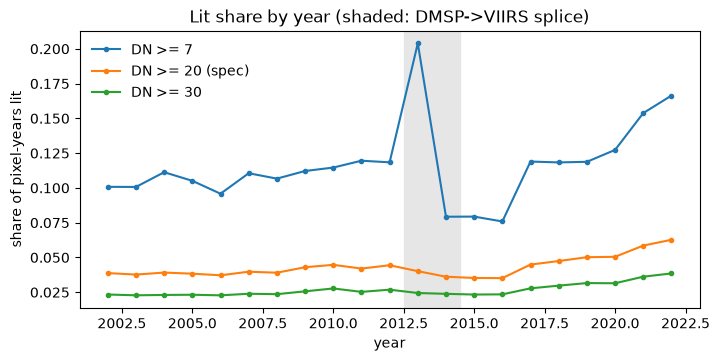

,is_flare,n,ntl_mean,ntl_median,night_lst_mean
0,0,11915493,3.364,0.00,284.673
1,1,117671,19.503,11.49,282.521


In [3]:
ls = sql(f"""SELECT year, avg((ntl_harm >= 7)::INT) AS dn7, avg((ntl_harm >= 20)::INT) AS dn20,
                   avg((ntl_harm >= 30)::INT) AS dn30
            FROM {P} WHERE {BASE} GROUP BY year ORDER BY year""")
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.axvspan(2012.5, 2014.5, color="0.9", zorder=0)
for c, lab in [("dn7", "DN >= 7"), ("dn20", f"DN >= {NTL_HI} (spec)"), ("dn30", "DN >= 30")]:
    ax.plot(ls.year, ls[c], "o-", ms=3, label=lab)
ax.set(xlabel="year", ylabel="share of pixel-years lit", title="Lit share by year (shaded: DMSP->VIIRS splice)")
ax.legend(frameon=False)
plt.show()

sql(f"""SELECT is_flare, count(*) AS n, avg(ntl_harm) AS ntl_mean, median(ntl_harm) AS ntl_median,
               avg({Y}) AS night_lst_mean
        FROM {P} WHERE era <> 'dmsp' GROUP BY 1 ORDER BY 1""").round(3)

**Result.** Lit share by year:

| | 2002–12 | 2013 | 2014–16 | 2017–20 | 2021–22 |
|---|---|---|---|---|---|
| DN ≥ 7 | 9.6–12.0 % | **20.4 %** | **7.6–7.9 %** | 11.8–12.7 % | 15.4–16.6 % |
| DN ≥ 20 (spec) | 3.7–4.5 % | 4.0 % | 3.5 % | 4.5–5.1 % | 5.9–6.3 % |
| DN ≥ 30 | 2.3–2.8 % | 2.4 % | 2.3–2.4 % | 2.8–3.2 % | 3.6–3.9 % |

Flare pixel-years (VIIRS era, 117 k of 12.0 M) average 19.5 DN vs 3.4, and nights 2.2 K cooler.

**Interpretation.** The splice artefact at DN 7 (a doubling in 2013, then a collapse) is gone at
DN 20. What remains is a mild 2014–16 dip of about 0.5 pp. The flare rows are few but sit in the
bright tail, so the mask stays.

## P3. Outcome measurement: compositing selection

The annual night LST averages clear-sky 8-day composites. If lights, mines or haze change how
often a pixel is observed, the annual mean is a selected mean. `cov_night` and `cov_day` are
this year's valid pixel-months divided by the pixel's best year. The raw counts are sums over
~100 native cells, so they are not comparable across pixels.

`cov_day` on PM2.5 asks whether hazy years lose daytime observations. That would hide part of
the aerosol cooling that C4 looks for.

Aqua drift is done elsewhere ([`drift-and-pm25-coverage-checks.md`](../../docs/analysis/drift-and-pm25-coverage-checks.md)
§1): negligible through 2022.

In [4]:
PM = f"{M} IS NOT NULL"
p3 = {
    "cov_night ~ lights":  (fit(f"cov_night ~ {XLOG} | {FE}"), XLOG),
    "cov_night ~ mines":   (fit(f"cov_night ~ {Z} | {FE}"), Z),
    "cov_night ~ PM2.5":   (fit(f"cov_night ~ {M} | {FE}", subset=PM), M),
    "cov_day ~ PM2.5":     (fit(f"cov_day ~ {M} | {FE}", subset=f"{PM} AND cov_day IS NOT NULL"), M),
}
p3_tab = pd.DataFrame({k: row(m, t) for k, (m, t) in p3.items()}).T[["est", "se", "p"]].astype(float).round(5)
b = p3_tab.loc["cov_night ~ lights", "est"]
print(f"P3 rule: d cov_night / d lights = {b:+.4f} -> selection "
      f"{'MATERIAL (C1 adds a coverage-restricted TWFE)' if abs(b) > 0.01 else 'not material'}")
p3_tab

P3 rule: d cov_night / d lights = +0.0002 -> selection not material


,est,se,p
cov_night ~ lights,0.00018,0.00037,0.63405
cov_night ~ mines,0.00124,0.00058,0.03162
cov_night ~ PM2.5,0.00013,0.00009,0.13408
cov_day ~ PM2.5,-0.00005,0.00008,0.56413


**Result.** With the §2 FE and ADM1 clusters:

| | estimate | SE | p |
|---|---:|---:|---:|
| `cov_night` ~ lights | +0.0002 | 0.0004 | 0.63 |
| `cov_night` ~ mines | +0.0012 | 0.0006 | 0.03 |
| `cov_night` ~ PM2.5 | +0.0001 | 0.0001 | 0.13 |
| `cov_day` ~ PM2.5 | −0.0001 | 0.0001 | 0.56 |

**Interpretation.** ◇ Not material: one log point of lights moves night coverage by 0.02 pp,
far below the 1 pp threshold. So C1 does not need a coverage-restricted TWFE (it reports one
anyway). Mines raise coverage by 0.1 pp per mine, which is detectable but tiny; R4 in the
post-analysis already shows the 2SLS is unchanged on high-coverage pixel-years. Hazy years do
not lose daytime observations in this measure, so the MODIS composite is not visibly dropping
aerosol-heavy periods. That rests on the within-pixel coverage proxy only. Seasonal detail would
need monthly bands.

## P4. Instrument

Where the instrument's variation lives, how exposed and unexposed pixels differ in levels (what
pixel FE must absorb), and the first stage with its profile across neighbouring cells. Ring 1 is
the 8 adjacent cells (10–14 km) and ring 2 the next 16 (20–28 km). With one instrument, the own-cell
2SLS estimates Σ_r β_r · π_r / π_0
([`10km-ring-check.md`](../../docs/analysis/10km-ring-check.md)).

In [5]:
display(sql(f"""
    SELECT avg(({Z} > 0)::INT) AS share_pixel_years_exposed,
           count(DISTINCT CASE WHEN {Z} > 0 THEN pixel_id END) AS pixels_ever_exposed
    FROM {P} WHERE {BASE}"""))
sql(f"""
    WITH e AS (SELECT pixel_id, max(({Z} > 0)::INT) AS mine_ever FROM {P} GROUP BY pixel_id)
    SELECT mine_ever, count(DISTINCT pixel_id) AS pixels, avg({Y}) AS night_lst,
           avg({XLOG}) AS log_ntl, avg({M}) AS pm25
    FROM {P} JOIN e USING (pixel_id) WHERE {BASE} GROUP BY 1 ORDER BY 1""").round(3)

,share_pixel_years_exposed,pixels_ever_exposed
0,0.057663,88414


,mine_ever,pixels,night_lst,log_ntl,pm25
0,0,1117058,284.678,0.513,19.321
1,1,88422,281.643,0.769,16.260


In [6]:
fs     = fit(f"{XLOG} ~ {Z} | {FE}")
fs_nb1 = fit(f"log_ntl_nb1 ~ {Z} | {FE}", subset="log_ntl_nb1 IS NOT NULL")
fs_nb2 = fit(f"log_ntl_nb2 ~ {Z} | {FE}", subset="log_ntl_nb2 IS NOT NULL")
r = row(fs, Z)
F = (r["est"] / r["se"]) ** 2
print(f"first-stage F (cluster-robust, single instrument): {F:.1f} -> "
      f"{'AR inference only' if F < 10 else 'Wald and AR both reported'}")
prof = reg_table([fs, fs_nb1, fs_nb2], ["own cell", "ring 1 (10-14 km)", "ring 2 (20-28 km)"], Z)
prof["pi / pi_own"] = (prof["estimate"] / prof["estimate"].iloc[0]).round(2)
prof

first-stage F (cluster-robust, single instrument): 71.0 -> Wald and AR both reported


,estimate,std_error,p,pi / pi_own
spec,,,,
own cell,0.0642,0.0076,0.0,1.00
ring 1 (10-14 km),0.0545,0.0070,0.0,0.85
ring 2 (20-28 km),0.0326,0.0061,0.0,0.51


**Result.** 5.8 % of pixel-years have a mine within 20 km (88 k pixels ever). Ever-exposed
pixels are 3.0 K cooler at night, brighter (`log1p` 0.77 vs 0.51) and less polluted
(16.3 vs 19.3 µg/m³) than never-exposed pixels. First stage 0.064 (0.008), **F = 71**. The π
profile is 1.00 / 0.85 / 0.51 (own cell / ring 1 / ring 2).

**Interpretation.** The level differences are large relative to any plausible effect, so pixel
FE are essential; they absorb the levels. The first stage is strong: ◇ both Wald and AR are
reported. The own-cell 2SLS estimates about β_0 + 0.85·β_1 + 0.51·β_2, the same profile as the
ring check.

## P5. PM2.5 as a measure of the mediator

C4 controls for ACAG PM2.5. A control that is noisy, or smoothed over a larger area than the
cell, under-controls. ACAG combines satellite AOD with a chemical transport model that runs at a
much coarser resolution than 10 km, so part of its within-cell year-to-year variation may be
regional.

The test is the within-FE r² between a cell's PM2.5 and the mean over its 8 neighbours. With
FWL, it equals the product of the two slopes (cell on neighbours, neighbours on cell) under the
same FE and sample. Lights give the benchmark, a variable known to carry local signal.

The clear-sky coverage check of ACAG is done
([`drift-and-pm25-coverage-checks.md`](../../docs/analysis/drift-and-pm25-coverage-checks.md) §2):
the instrument does not move ACAG's likely data support.

In [7]:
def within_r2(a, b):
    sub = f"{a} IS NOT NULL AND {b} IS NOT NULL"
    ab, ba = row(fit(f"{a} ~ {b} | {FE}", subset=sub), b), row(fit(f"{b} ~ {a} | {FE}", subset=sub), a)
    return dict(slope_cell_on_ring1=ab["est"], slope_ring1_on_cell=ba["est"], within_r2=ab["est"] * ba["est"])

p5 = pd.DataFrame({"PM2.5": within_r2(M, f"{M}_nb1"), "log1p(ntl_harm)": within_r2(XLOG, f"{XLOG}_nb1")}).T.round(3)
r2 = p5.loc["PM2.5", "within_r2"]
print(f"P5 rule: within-FE r2(PM2.5, ring-1 mean) = {r2:.3f} -> "
      f"{'C4 speaks to regional aerosol only' if r2 >= 0.9 else 'PM2.5 carries cell-local variation'}")
p5

P5 rule: within-FE r2(PM2.5, ring-1 mean) = 0.971 -> C4 speaks to regional aerosol only


,slope_cell_on_ring1,slope_ring1_on_cell,within_r2
PM2.5,1.016,0.955,0.971
log1p(ntl_harm),0.991,0.487,0.483


**Result.** Within-FE r² with the ring-1 mean: **PM2.5 0.971** (slopes 1.02 and 0.96);
**lights 0.483** (slopes 0.99 and 0.49).

**Interpretation.** ◇ **r² ≥ 0.9: C4 speaks to regional aerosol only.** After pixel and
country × biome × year FE, a cell's ACAG PM2.5 moves almost one-for-one with its neighbours'
mean. At 10 km, ACAG carries essentially no cell-local year-to-year variation. Lights do: half
their within variation is local.

So a PM2.5 control can absorb at most a *regional* aerosol channel. It cannot absorb a local
one, where lights growth brings local emissions that cool the cell. A null in C4 is not
evidence against a local pollution channel. This is a limit of the measure at this resolution,
not a finding about the physics.

## Summary

| Block | Result | ◇ |
|---|---|---|
| P1 | 25.3 M pixel-years, 2002–2022; same rows as the former `regression.ipynb` | — |
| P2 | DN 20 removes the DMSP→VIIRS artefact (a mild 2014–16 dip remains); flares masked | — |
| P3 | Night coverage does not respond to lights (+0.0002) or PM2.5. Mines +0.0012 per mine. | selection not material |
| P4 | F = 71; π profile 1.00 / 0.85 / 0.51 | Wald and AR both valid |
| P5 | PM2.5 within-FE r² with its ring-1 mean = 0.97 (lights 0.48) | **C4 speaks to regional aerosol only** |

**What this means for the core.** The IV side rests on sound ground: the first stage is strong
and the outcome is not visibly selected. The PM2.5 side does not. ACAG at 10 km cannot
represent a local pollution channel, so the core's PM2.5 control test can at best rule out a
regional aerosol explanation of the TWFE coefficient.